**Vấn đề của tiếng Việt**
Khác với tiếng Anh, tiếng Việt thuộc vào loại ngôn ngữ đơn lập (hay còn gọi là ngôn ngữ cách thể).

```Ngôn ngữ đơn lập là loại hình ngôn ngữ mà trong đó từ vựng hoàn toàn không biến đổi về mặt hình thái, chúng giữ nguyên hình thức phát âm dù đứng độc lập hay được đặt trong câu. Vì bản thân mỗi từ không tự thể hiện mối quan hệ hay chức năng cú pháp (chúng đứng cạnh nhau một cách biệt lập), ngôn ngữ này bắt buộc phải sử dụng các công cụ bổ trợ như hư từ, trật tự từ và ngữ điệu để biểu đạt các ý nghĩa và mối quan hệ ngữ pháp.```
- Về mặt ngữ âm: Trong tiếng Anh, dấu cách dùng để phân tách các từ. Nhưng trong tiếng Việt, do tính đơn tiết, dấu cách chỉ dùng để phân tách các âm tiết. Một từ tiếng Việt có thể gồm 1, 2, hoặc hơn 3 âm tiết (ví dụ: sinh viên, hợp tác xã,...). Cho nên, bước đầu tiên và quan trọng nhất là phải thực hiện tách từ.
- Về mặt nhập nhằng ngữ nghĩa: Một hệ quả của tiếng Việt là hiện tượng từ nhiều nghĩa / từ đồng âm khác nghĩa cực kỳ phổ biến (ví dụ: cùng 1 giảng có thể kết hợp thêm 1 từ khác để tạo thành 1 từ phức mang ý nghĩa khác: giảng dạy, giảng viên, bài giảng,...). Ngoài ra, trong một câu có thể cùng hiểu theo nhiều sắc thái (ví dụ: có vài buổi thầy " tận dụng " tụi em để khiêng bàn ghế cho trường , cũng vui nhưng hơi mệt.)


# **1. CHUẨN BỊ DỮ LIỆU**

In [2]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from underthesea import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

In [3]:
df_train = pd.read_csv('train.csv')
df_val = pd.read_csv('validation.csv')
df_test = pd.read_csv('test.csv')

def segment_vietnamese_text(text):
    return word_tokenize(str(text), format="text")

X_train_seg = df_train['sentence'].apply(segment_vietnamese_text)
X_val_seg = df_val['sentence'].apply(segment_vietnamese_text)
X_test_seg = df_test['sentence'].apply(segment_vietnamese_text)

y_train_sent = df_train['sentiments']
y_val_sent = df_val['sentiments']
y_test_sent = df_test['sentiments']
sentiment_names = ['Tiêu cực', 'Trung lập', 'Tích cực']

y_train_topic = df_train['topics'] 
y_val_topic = df_val['topics']
y_test_topic = df_test['topics']
topic_names = ['Giảng viên', 'Chương trình', 'Cơ sở vật chất', 'Khác']

Tổng cộng: 16,175 câu)

[ 1. PHÂN PHỐI CẢM XÚC (SENTIMENT) ]
Tên Nhãn                 Train                 Validation            Test                  TỔNG CỘNG      
----------------------------------------------------------------------------------------------------------
Tiêu cực                 5325    ( 46.6%)      705     ( 44.5%)      1409    ( 44.5%)      7439    ( 46.0%)
Trung lập                458     (  4.0%)      73      (  4.6%)      167     (  5.3%)      698     (  4.3%)
Tích cực                 5643    ( 49.4%)      805     ( 50.9%)      1590    ( 50.2%)      8038    ( 49.7%)

[ 2. PHÂN PHỐI CHỦ ĐỀ (TOPIC) ]
Tên Nhãn                 Train                 Validation            Test                  TỔNG CỘNG      
----------------------------------------------------------------------------------------------------------
Giảng viên               8166    ( 71.5%)      1151    ( 72.7%)      2290    ( 72.3%)      11607   ( 71.8%)
Chương trình             2201    ( 19.3%)     

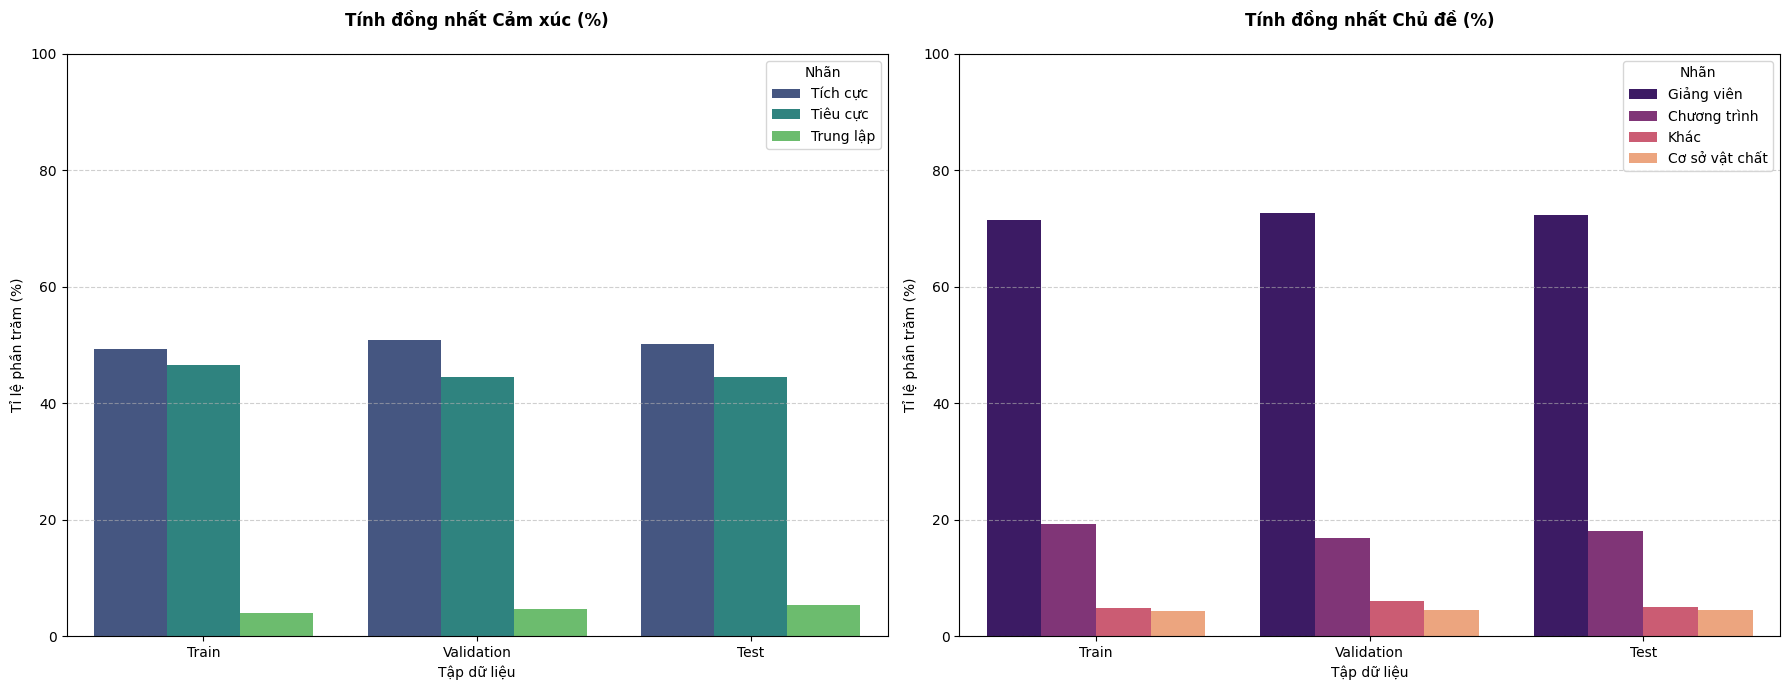

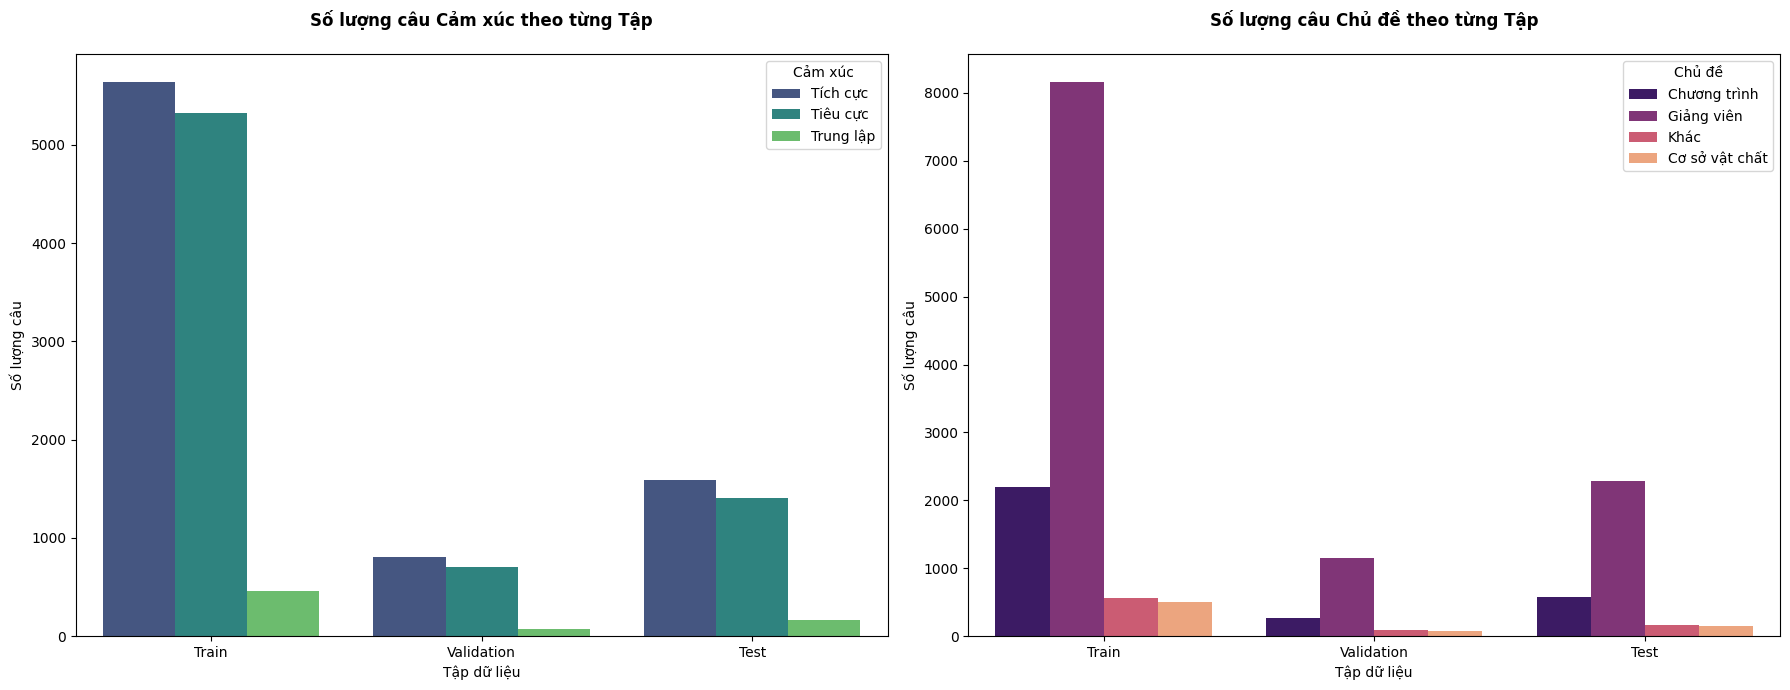

In [ ]:
df_train['set'] = 'Train'
df_val['set'] = 'Validation'
df_test['set'] = 'Test'
df_all = pd.concat([df_train, df_val, df_test])

total_sentences = len(df_all)

def print_comprehensive_report(df_full, label_col, label_names, title):
    print(f"\n{title.upper()}")
    
    stats = df_full.groupby(['set', label_col]).size().unstack(fill_value=0)
    stats = stats.reindex(['Train', 'Validation', 'Test'])
    set_totals = stats.sum(axis=1)
    
    header = f"{'Tên Nhãn':<25}" + "".join([f"{s:<22}" for s in stats.index]) + f"{'TỔNG CỘNG':<15}"
    print(header)
    print("-" * len(header))
    
    for idx, name in enumerate(label_names):
        row_str = f"{name:<25}"
        total_label = 0
        for s in stats.index:
            count = stats.loc[s, idx]
            pct = (count / set_totals[s]) * 100
            total_label += count
            row_str += f"{count:<7} ({pct:>5.1f}%)      "
        
        overall_pct = (total_label / total_sentences) * 100
        row_str += f"{total_label:<7} ({overall_pct:>5.1f}%)"
        print(row_str)

print(f"Tổng cộng: {total_sentences:,} câu")

print_comprehensive_report(df_all, 'sentiments', sentiment_names, "[ 1. Phân phối Cảm xúc (Sentiment) ]")
print_comprehensive_report(df_all, 'topics', topic_names, "[ 2. Phân phối Chủ đề (Topic) ]")

df_all['word_count'] = df_all['sentence'].apply(lambda x: len(str(x).split()))
print("\n" + "-"*90)
print("[ 3. THỐNG KÊ ĐẶC TRƯNG ĐỘ DÀI VĂN BẢN (SỐ TỪ) ]")
print(f"- Số từ trung bình mỗi câu: {df_all['word_count'].mean():.1f} từ")
print(f"- Câu ngắn nhất: {df_all['word_count'].min()} từ")
print(f"- Câu dài nhất: {df_all['word_count'].max()} từ")
print("-"*90)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def plot_percentage_by_set(df, col, names, ax, title, palette):
    prop_df = (df.groupby(['set'])[col]
               .value_counts(normalize=True)
               .rename('percentage')
               .mul(100)
               .reset_index())
    
    prop_df['label_name'] = prop_df[col].map({i: name for i, name in enumerate(names)})
    
    sns.barplot(data=prop_df, x='set', y='percentage', hue='label_name', 
                palette=palette, ax=ax, order=['Train', 'Validation', 'Test'])
    
    ax.set_title(title, fontweight='bold', pad=20)
    ax.set_ylabel('Tỉ lệ phần trăm (%)')
    ax.set_xlabel('Tập dữ liệu')
    ax.set_ylim(0, 100)
    ax.legend(title='Nhãn', loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plot_percentage_by_set(df_all, 'sentiments', sentiment_names, axes[0], 'Tính đồng nhất Cảm xúc (%)', 'viridis')
plot_percentage_by_set(df_all, 'topics', topic_names, axes[1], 'Tính đồng nhất Chủ đề (%)', 'magma')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

df_plot = df_all.copy()
df_plot['sentiment_label'] = df_plot['sentiments'].map({i: n for i, n in enumerate(sentiment_names)})
df_plot['topic_label'] = df_plot['topics'].map({i: n for i, n in enumerate(topic_names)})

sns.countplot(data=df_plot, x='set', hue='sentiment_label', palette='viridis', 
              ax=axes[0], order=['Train', 'Validation', 'Test'])
axes[0].set_title('Số lượng câu Cảm xúc theo từng Tập', fontweight='bold', pad=20)
axes[0].set_ylabel('Số lượng câu')
axes[0].set_xlabel('Tập dữ liệu')
axes[0].legend(title='Cảm xúc')

sns.countplot(data=df_plot, x='set', hue='topic_label', palette='magma', 
              ax=axes[1], order=['Train', 'Validation', 'Test'])
axes[1].set_title('Số lượng câu Chủ đề theo từng Tập', fontweight='bold', pad=20)
axes[1].set_ylabel('Số lượng câu')
axes[1].set_xlabel('Tập dữ liệu')
axes[1].legend(title='Chủ đề')

plt.tight_layout()
plt.show()

Dựa trên số liệu thống kê, ta nhận thấy được dữ liệu có các đặc điểm sau

# **2. HÀM TRỰC QUAN HÓA**

In [7]:
def plot_grid_search_heatmap(grid_search_obj, title, cmap):
    plt.figure(figsize=(9, 7))
    results_df = pd.DataFrame(grid_search_obj.cv_results_)
    heat_data = results_df[['param_tfidf__max_df', 'param_svm__C', 'mean_test_score']]
    pivot_table = heat_data.pivot(index='param_tfidf__max_df', columns='param_svm__C', values='mean_test_score')
    
    sns.heatmap(pivot_table * 100, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 'Macro F1-Score (%)'})
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Ngưỡng cắt từ phổ biến (max_df)', fontsize=12)
    plt.xlabel('Hệ số điều chuẩn SVM (C)', fontsize=12)
    plt.tight_layout()
    plt.show()

# **3. PHÂN LOẠI CẢM XÚC**

In [8]:
pipeline_sent = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), norm='l2', min_df=5)),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
])

In [9]:
param_grid_sent = {
    'tfidf__max_df': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'svm__C': [0.2, 0.4, 0.6, 0.8, 1.0, 5.0, 10.0]
}

In [10]:
start_time = time.time()

grid_search_sent = GridSearchCV(
    estimator=pipeline_sent, 
    param_grid=param_grid_sent, 
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

In [11]:
grid_search_sent.fit(X_train_seg, y_train_sent)

Fitting 5 folds for each of 63 candidates, totalling 315 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.2, 0.4, ...], 'tfidf__max_df': [0.1, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [12]:
print(f"\nHoàn tất sau: {time.time() - start_time:.2f} giây")
print(f"CẶP THAM SỐ TÌM ĐƯỢC: {grid_search_sent.best_params_}")
print(f"F1-Macro cao nhất trên tập Train (CV): {grid_search_sent.best_score_*100:.2f}%")


Hoàn tất sau: 10.83 giây
CẶP THAM SỐ TÌM ĐƯỢC: {'svm__C': 0.4, 'tfidf__max_df': 0.3}
F1-Macro cao nhất trên tập Train (CV): 73.55%


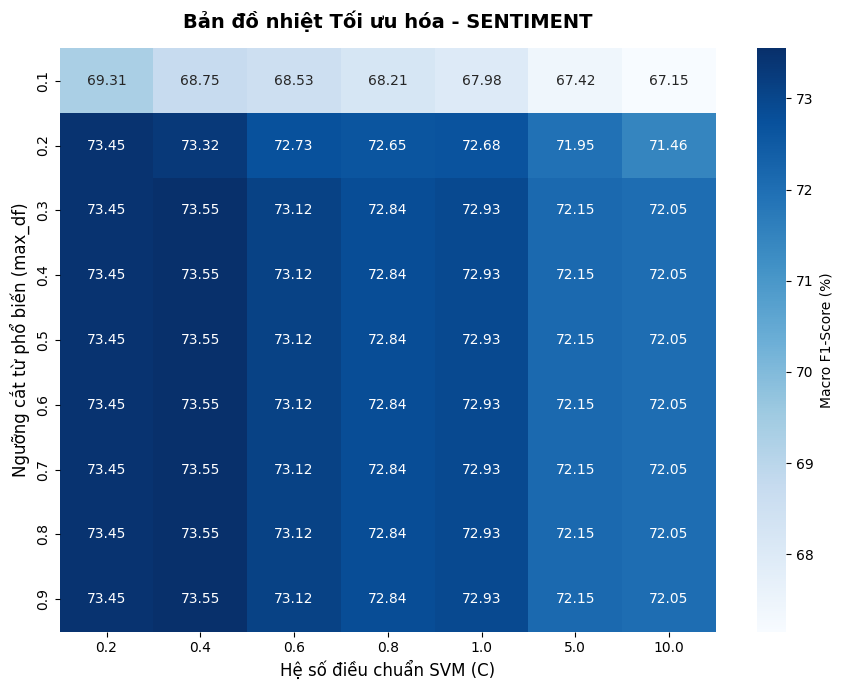

In [13]:
plot_grid_search_heatmap(grid_search_sent, "Bản đồ nhiệt Tối ưu hóa - SENTIMENT", "Blues")

In [14]:
best_sent_model = grid_search_sent.best_estimator_

y_val_pred_sent = best_sent_model.predict(X_val_seg)
y_test_pred_sent = best_sent_model.predict(X_test_seg)

In [15]:
print("="*60)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION")
print("="*60)
print(f"Accuracy: {accuracy_score(y_val_sent, y_val_pred_sent)*100:.2f}% | Macro F1: {f1_score(y_val_sent, y_val_pred_sent, average='macro')*100:.2f}%\n")
print(classification_report(y_val_sent, y_val_pred_sent, target_names=sentiment_names))

print("\n" + "="*60)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test_sent, y_test_pred_sent)*100:.2f}% | Macro F1: {f1_score(y_test_sent, y_test_pred_sent, average='macro')*100:.2f}%\n")
print(classification_report(y_test_sent, y_test_pred_sent, target_names=sentiment_names))

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION
Accuracy: 89.26% | Macro F1: 75.42%

              precision    recall  f1-score   support

    Tiêu cực       0.91      0.90      0.91       705
   Trung lập       0.36      0.52      0.42        73
    Tích cực       0.95      0.92      0.93       805

    accuracy                           0.89      1583
   macro avg       0.74      0.78      0.75      1583
weighted avg       0.91      0.89      0.90      1583


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
Accuracy: 87.52% | Macro F1: 73.36%

              precision    recall  f1-score   support

    Tiêu cực       0.89      0.91      0.90      1409
   Trung lập       0.35      0.44      0.39       167
    Tích cực       0.94      0.89      0.91      1590

    accuracy                           0.88      3166
   macro avg       0.72      0.75      0.73      3166
weighted avg       0.88      0.88      0.88      3166



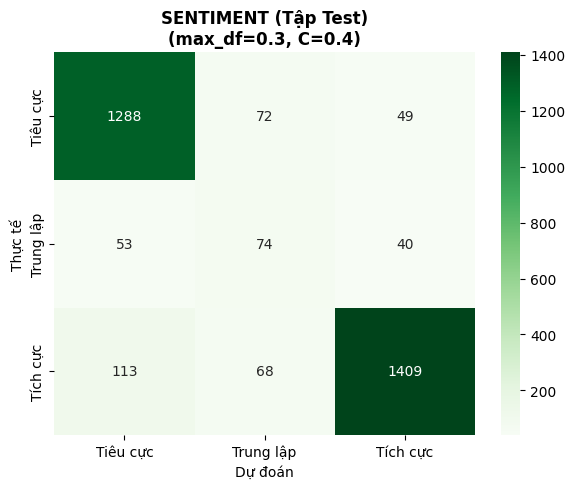

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_sent, y_test_pred_sent), annot=True, fmt='d', cmap='Greens', 
            xticklabels=sentiment_names, 
            yticklabels=sentiment_names)
plt.title(f"SENTIMENT (Tập Test)\n(max_df={grid_search_sent.best_params_['tfidf__max_df']}, C={grid_search_sent.best_params_['svm__C']})", fontweight='bold')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

# **4. PHÂN LOẠI CHỦ ĐỀ**

In [17]:
pipeline_topic = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), norm='l2', min_df=5)),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000))
])

In [18]:
param_grid_topic = {
    'tfidf__max_df': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    'svm__C': [0.2, 0.4, 0.6, 0.8, 1.0, 5.0, 10.0]
}

In [19]:
start_time_topic = time.time()

grid_search_topic = GridSearchCV(
    estimator=pipeline_topic, 
    param_grid=param_grid_topic, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=1
)

In [20]:
grid_search_topic.fit(X_train_seg, y_train_topic) 

Fitting 5 folds for each of 63 candidates, totalling 315 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.2, 0.4, ...], 'tfidf__max_df': [0.1, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [21]:
print(f"\nHoàn tất sau: {time.time() - start_time_topic:.2f} giây")
print(f"CẶP THAM SỐ TÌM ĐƯỢC (TOPIC): {grid_search_topic.best_params_}")
print(f"F1-Macro cao nhất trên tập Train (CV): {grid_search_topic.best_score_*100:.2f}%")


Hoàn tất sau: 8.37 giây
CẶP THAM SỐ TÌM ĐƯỢC (TOPIC): {'svm__C': 0.2, 'tfidf__max_df': 0.3}
F1-Macro cao nhất trên tập Train (CV): 72.17%


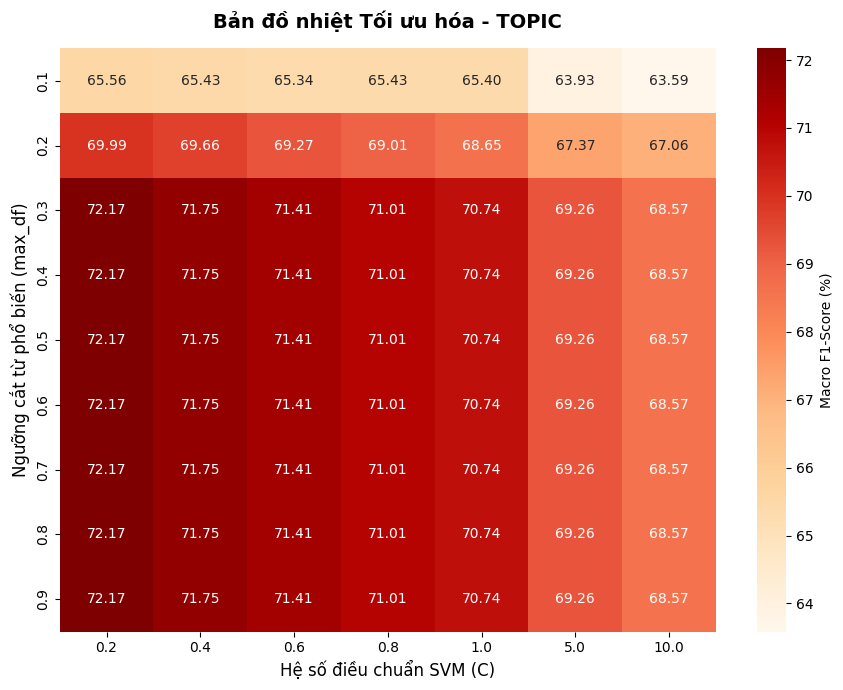

In [22]:
plot_grid_search_heatmap(grid_search_topic, "Bản đồ nhiệt Tối ưu hóa - TOPIC", "OrRd")

In [23]:
best_topic_model = grid_search_topic.best_estimator_

y_val_pred_topic = best_topic_model.predict(X_val_seg)
y_test_pred_topic = best_topic_model.predict(X_test_seg)

In [24]:
print("="*60)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (TOPIC)")
print("="*60)
print(f"Accuracy: {accuracy_score(y_val_topic, y_val_pred_topic)*100:.2f}% | Macro F1: {f1_score(y_val_topic, y_val_pred_topic, average='macro')*100:.2f}%\n")
print(classification_report(y_val_topic, y_val_pred_topic, target_names=topic_names))

print("\n" + "="*60)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (TOPIC)")
print("="*60)
print(f"Accuracy: {accuracy_score(y_test_topic, y_test_pred_topic)*100:.2f}% | Macro F1: {f1_score(y_test_topic, y_test_pred_topic, average='macro')*100:.2f}%\n")
print(classification_report(y_test_topic, y_test_pred_topic, target_names=topic_names))

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VALIDATION (TOPIC)
Accuracy: 83.70% | Macro F1: 72.19%

                precision    recall  f1-score   support

    Giảng viên       0.94      0.88      0.91      1151
  Chương trình       0.65      0.77      0.70       267
Cơ sở vật chất       0.84      0.87      0.85        70
          Khác       0.39      0.45      0.42        95

      accuracy                           0.84      1583
     macro avg       0.70      0.74      0.72      1583
  weighted avg       0.85      0.84      0.84      1583


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (TOPIC)
Accuracy: 83.35% | Macro F1: 72.77%

                precision    recall  f1-score   support

    Giảng viên       0.94      0.87      0.91      2290
  Chương trình       0.64      0.74      0.68       572
Cơ sở vật chất       0.86      0.93      0.89       145
          Khác       0.36      0.52      0.43       159

      accuracy                           0.83      3166
     macro avg       0.70      0.76      0.73      3

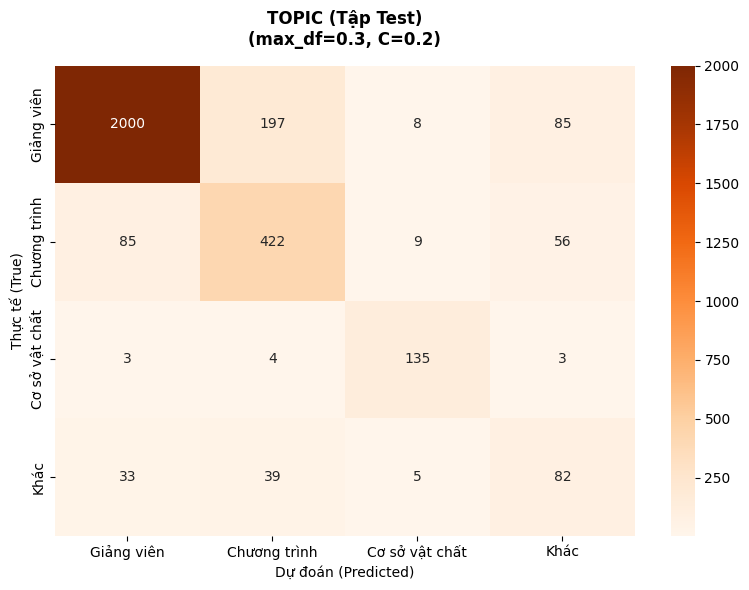

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_topic, y_test_pred_topic), annot=True, fmt='d', cmap='Oranges', 
            xticklabels=topic_names, 
            yticklabels=topic_names)

best_max_df_topic = grid_search_topic.best_params_['tfidf__max_df']
best_c_topic = grid_search_topic.best_params_['svm__C']

plt.title(f"TOPIC (Tập Test)\n(max_df={best_max_df_topic}, C={best_c_topic})", fontweight='bold', pad=15)
plt.ylabel('Thực tế (True)')
plt.xlabel('Dự đoán (Predicted)')
plt.tight_layout()
plt.show()